# Assignment 3
### Due 9/21. Do four of five.

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('data/nhanes_data_17_18.csv')
#data.head()

var1 = data['GeneralHealthCondition']
var2 = data['Past30DayMilkProductConsumption']

#NA Analysis
print(var1.isna().sum())
print(var2.isna().sum())

2402
1


C:\Users\maxel\AppData\Local\Temp\ipykernel_29776\2619031589.py:6: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/nhanes_data_17_18.csv')


In [4]:
table = pd.crosstab(var1, var2)
table

Past30DayMilkProductConsumption,Never,Often-once a day or more?,Rarely-less than once a week,Sometimes-once a week or more but less than once a day or,Varied
GeneralHealthCondition,,,,,
Excellent,98,263,96,161,1
Fair or,254,315,271,330,5
Good,460,763,512,706,12
Poor?,35,49,42,46,0
Very good,294,478,303,467,2


It's interesting, though unsurprising, that the most moderate option for health condition is the most dense by total number of entries, though I do find it fascinating as I would expect most people to rate a healthy individual as someone with 'excellent' health rather than just 'good'. Are there preconditions here? What's the rating criteria? What differentiates 'good' health from 'fair', 'excellent', 'poor', or 'very good'? Additionally, I don't see a huge relation with how often milk is being consumed to the health rating. The proportions seem to hold relatively stable.

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [5]:
data

var1 = var1
var2 = data['WeightKg'].astype(float)

#NA Analysis
print(var1.isna().sum())
print(var2.isna().sum())

2402
124


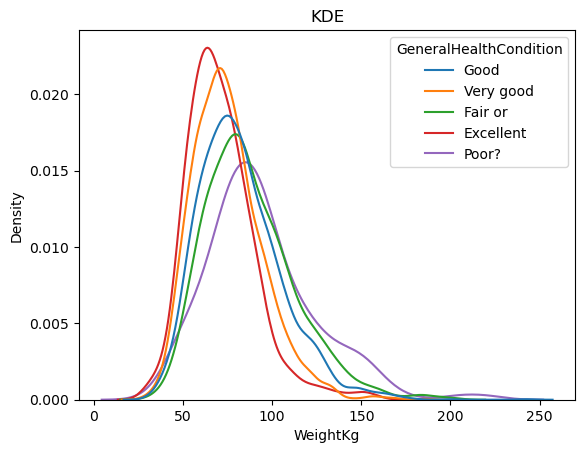

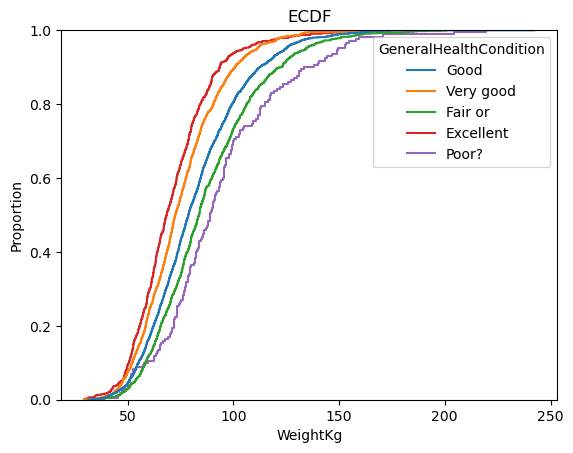

In [6]:
sns.kdeplot(data, x = var2, hue = var1, common_norm=False ).set(title='KDE')
plt.show()

sns.ecdfplot(data, x= var2, hue = var1).set(title='ECDF')
plt.show()


In [7]:
data[['WeightKg', 'GeneralHealthCondition']].groupby(var1).describe()

WeightKg                                             \
                          count       mean        std   min     25%    50%   
GeneralHealthCondition                                                       
Excellent                 612.0  71.188399  19.169784  29.4  58.475  68.45   
Fair or                  1152.0  87.445920  25.361884  33.4  69.300  83.80   
Good                     2431.0  81.973015  23.289469  31.4  65.200  78.70   
Poor?                     170.0  93.521176  30.141754  36.8  73.550  89.05   
Very good                1534.0  75.136441  19.746632  29.3  60.700  72.50   

                                        
                            75%    max  
GeneralHealthCondition                  
Excellent                80.725  158.7  
Fair or                 101.700  200.9  
Good                     95.200  242.6  
Poor?                   109.275  219.6  
Very good                85.800  185.0

Based on the above density plots and and tables, it seems there is evidence that general health rating of the patient could be associated with the individual's weight, something that makes sense on a surface level as it's incredibly easy to measure and can be associated with health risks. That said, is the weight of the patient misaligning where a patient should acutally be labeled? What is breaking the tie, if anything, for a patient in the 'in between' groups that keeps them from being a healthy/unhealthy person? Furthermore, it's interesting that heavier patients make up a far larger proportion of the data than lighter patients do, regardless of health diagnosis. In fact, there's very little difference in proportion across health score when the patient is 50 kg or less. This could be related to age, height, build, etc., but I'd be curious to dig into it more.

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

In [48]:
import numpy as np
import seaborn as sns
import pandas as pd

college = pd.read_csv('data/college_completion.csv')
cleaned  = college.dropna(subset=['med_sat_percentile', 'endow_percentile'])

var1 = cleaned['med_sat_percentile']
var2 = cleaned['endow_percentile']

(array([36.64248391, 36.39341023, 36.14988085, 35.91685604, 35.70018134,
        35.50644702, 35.34273466, 35.21624678, 35.13383687, 35.10148342,
        35.1237773 , 35.20350841, 35.34143479, 35.5362921 , 35.78505483,
        36.08340537, 36.42631902, 36.80864627, 37.22557544, 37.67288575,
        38.14694587, 38.64446392, 39.16204456, 39.69564977, 40.24008522,
        40.78863968, 41.33298512, 41.86340197, 42.36933558, 42.84022835,
        43.26652182, 43.6406932 , 43.95818307, 44.21808273, 44.42347463,
        44.58135416, 44.7021043 , 44.79854769, 44.88466151, 44.97410422,
        45.07875613, 45.20750186, 45.36546491, 45.5538367 , 45.77033358,
        46.01019096, 46.26749772, 46.53661598, 46.81343117, 47.09622817,
        47.38606995, 47.68664388, 48.00362583, 48.34368611, 48.71332291,
        49.11774688, 49.56004044, 50.04076199, 50.55806222, 51.10825172,
        51.68665111, 52.28850406, 52.90975497, 53.54756854, 54.20056208,
        54.86879758, 55.55361912, 56.25742092, 56.9

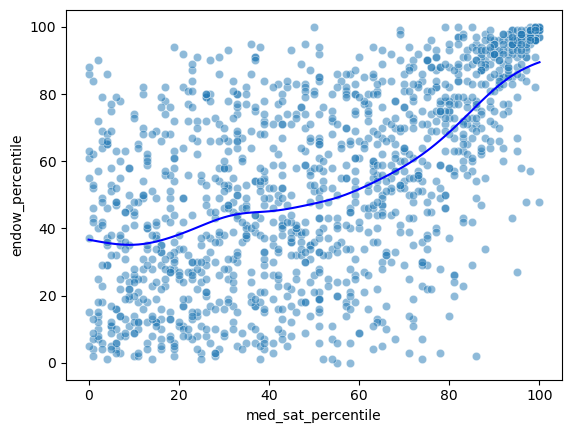

In [49]:
def lcls(x,y):
    n = len(x)
    grid = np.sort(x.unique())


    iqr = np.quantile(x,.75) - np.quantile(x,.25)
    #Silverman
    h = 0.9 * min(np.std(x), iqr/1.349) * len(x) **(-0.2)

    I = -(x.to_numpy().reshape(-1,1) - grid.reshape(1,-1) )**2
    K = np.exp(I/(2*h**2) )/np.sqrt(2*np.pi*h**2 )

    numerator = y@K
    denominator = np.sum(K,axis=0)

    y_hat = numerator/denominator

    sns.scatterplot(data=cleaned, x='med_sat_percentile', y='endow_percentile', alpha=.5)
    sns.lineplot(x=grid, y=y_hat, color='blue')

    return y_hat, grid



lcls(var1,var2)

The LCLS indicates that of the universities present in our sample, we tend to see schools with a higher endowment require higher median SAT scores on the average, though this finding is really only true for the most elite universities. This relationship isn't all that strong for the bulk of schools, as per our estimated LCLS regression, any school in the ~60th percentile or below for their SAT score requirement have roughly similar endowments. There's some upward trend, sure, but it's not nearly as extreme as the growth we see once we exceed this threshold.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

In [7]:
college = pd.read_csv('data/college_completion.csv')

var1 = college['med_sat_percentile']
var2 = college['endow_percentile']

college[['med_sat_percentile', 'endow_percentile']].groupby('endow_percentile').mean()

,med_sat_percentile
endow_percentile,
0.0,56.500000
1.0,37.285714
2.0,25.833333
3.0,32.777778
4.0,21.000000
...,...
96.0,93.562500
97.0,93.411765
98.0,92.285714


<Axes: xlabel='endow_percentile', ylabel='med_sat_percentile'>

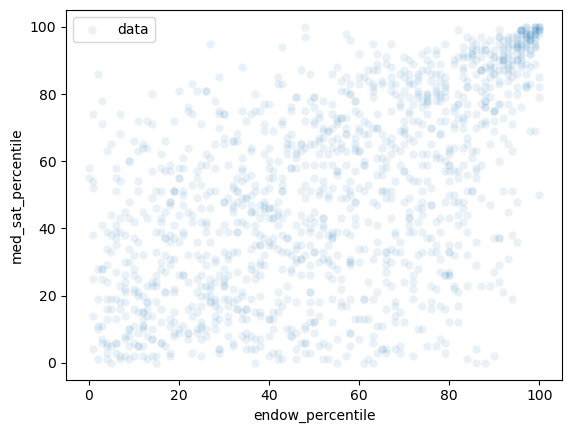

In [8]:
sns.scatterplot(data=college, x = 'endow_percentile', y = 'med_sat_percentile', alpha=.09, label='data')


While there's an argument for a strong correlation between a university's endowment and their average SAT score, it seems highly unlikely that these two would have absolute causality between one another. Perhaps higher achieving students go on to make more money and subsequently contribute more to their alma mater's endowment, but there's far too much noise in the data to make a strong causal argument. A school's endowment is far too removed from raw test scores to have a causal link, and other factors such as total student population, location, and years since founding are just some of the many other conflicting variables in this equation.

Setting aside confounding variables, if we were wanting to draw a conclusive causal relationship between a school's endowment rank and median SAT rank, a longitudinal study could be done on universities, analyzing how the schools incoming test scores fluctuate compared to their endowment. If inbound scores moved closely with a school's sitting endowment, you could begin to craft an argument for causality. This is obviously an unlikely outcome that ignores many practical considerations, but if this were to be a study, this is how it would have to be. 